In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv
import datetime
import os
import mplfinance as mpf
import re
import utils

In [2]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [3]:
query_min = "SELECT * FROM gold.active_1min ORDER BY bar_date, bar_time"
query_5min = "SELECT * FROM gold.active_5min ORDER BY bar_date, bar_time"
query_15min = "SELECT * FROM gold.active_15min ORDER BY bar_date, bar_time"
df_min = pd.read_sql(query_min,engine)
df_5min = pd.read_sql(query_5min,engine)
df_15min = pd.read_sql(query_15min,engine)

## Analyze Average Swing by Time

In [7]:
def analyze_swings_by_time(df,bucket,timeframe):
    df_swing= utils.get_swings(df)
    df_swing['profit'] = np.where(
        df_swing['trend']=='UP', 
        abs(df_swing['open']-df_swing['high']), 
        abs(df_swing['open']-df_swing['low'])
    )
    df_swing = utils.add_winsorized_col(df_swing,'profit')
    df_agg = utils.descriptive_groupby(df_swing,'bucket_'+bucket+'min','profit')
    df_agg_win = utils.descriptive_groupby(df_swing,'bucket_'+bucket+'min','profit_winsorized')
    
    utils.bar_chart(df_agg,'count',timeframe+' Minute Interval - '+bucket+' Minute Time Frame','Number of Swings')
    utils.bar_chart(df_agg,'mean',timeframe+' Minute Interval - '+bucket+' Minute Time Frame','Average Swing Magnitude',yerror=df_agg['std'])
    utils.bar_chart(df_agg_win,'mean',timeframe+' Minute Interval - '+bucket+' Minute Time Frame','Average Swing Magnitude Winsorized',yerror=df_agg_win['std'])

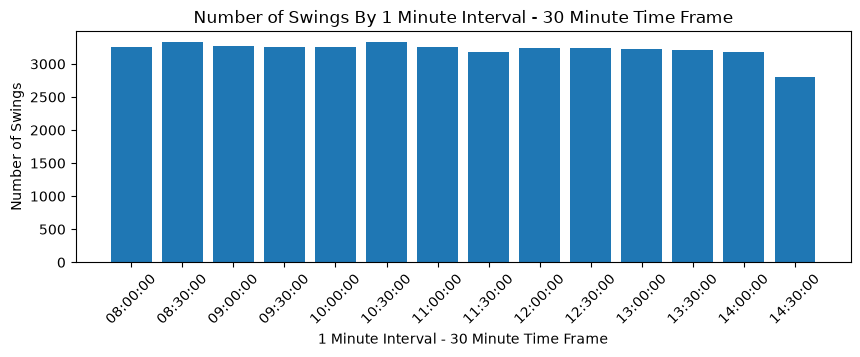

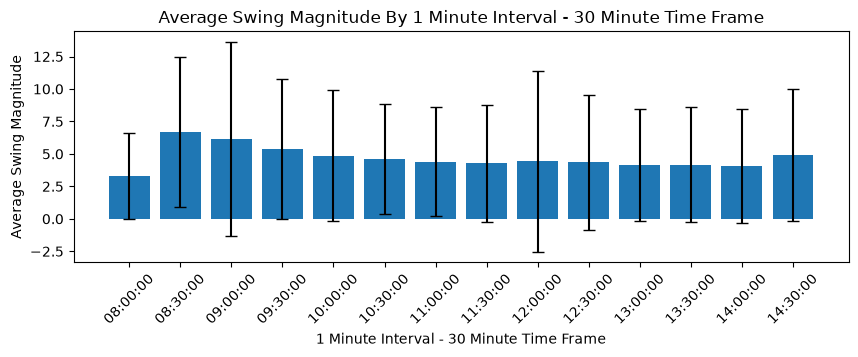

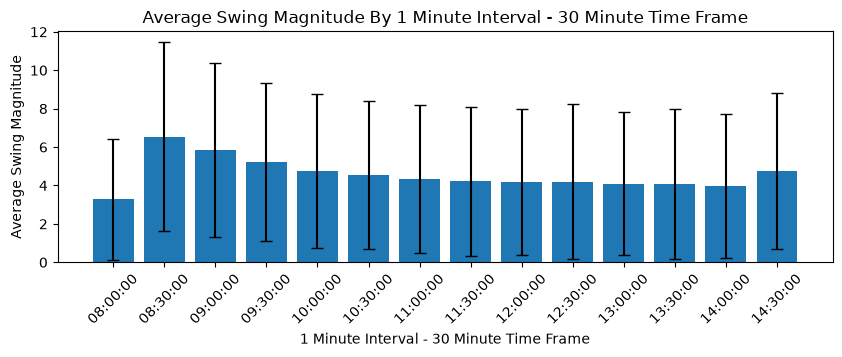

In [8]:
# display_swings(dataframe, time_bucket, time_frame)
# datframe can be set to [df_min, df_5min, df_15min]
# time_bucket can be set to [30,15,5]
analyze_swings_by_time(df_min,'30','1')